# 03 — Arm 2: Fine-tuned BERT classifier

Dataset C, AMLH coursework. `question` -> WordPiece (`max_length=48`) -> encoder -> 906-way
linear classification head -> argmax. `answer` is never an input to this arm. Labels are encoded
against the full 906-class training universe so the label space matches Arm 1 and the frozen
test run. No test-set cell anywhere in this notebook. All logic lives in `src/amlh/arm2_bert.py`;
this notebook only calls it, displays results, and persists tables to `artefacts/` and figures to
`figures/`. It runs standalone after a kernel restart by loading `artefacts/split_fit.csv` and
`artefacts/split_val.csv`.

**`QUICK_SMOKE_TEST`** (next cell): this environment is CPU-only, and the real frozen run
targets a Colab T4. Set to `True` to subsample fit/val and cut epochs down to a fast
correctness check — every cell still executes real code and prints real numbers, but the
printed hyperparameters at the end are **not** valid to freeze into `config.py`. Set to `False`
(on Colab, GPU available) for the real run whose output gets hand-copied into `config.py`.

In [1]:
QUICK_SMOKE_TEST = True

In [2]:
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch

from amlh import arm2_bert as ab
from amlh import evaluate
from amlh.config import ARTEFACTS_DIR, FIGURES_DIR, set_seed
from amlh.data import load_train

## 1. Load splits from `artefacts/`

In [3]:
set_seed()

fit = pd.read_csv(ARTEFACTS_DIR / "split_fit.csv")
val = pd.read_csv(ARTEFACTS_DIR / "split_val.csv")

if QUICK_SMOKE_TEST:
    # Subsample for a fast CPU correctness check only -- never for the frozen run.
    fit = fit.groupby("disease", group_keys=False)[fit.columns].apply(lambda g: g.head(1)).sample(
        n=40, random_state=44
    ).reset_index(drop=True)
    val = val.sample(n=20, random_state=44).reset_index(drop=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"
print(f"fit={len(fit)} ({fit.disease.nunique()} classes) | val={len(val)} ({val.disease.nunique()} classes)")
print(f"device={device} | gpu={gpu_name}")

fit=40 (40 classes) | val=20 (18 classes)
device=cpu | gpu=none


## 2. Label encoding over the full 906-class universe

In [4]:
label_to_id, id_to_label = ab.encode_labels(load_train())
assert len(label_to_id) == 906
print(f"{len(label_to_id)} classes encoded")

906 classes encoded


## 3. Tokenisation sanity check

`max_length=48` is fixed per `01_eda`'s question-length percentiles (mean 8.4 words, 99th
percentile 18) -- confirmed here on the fit split, not re-tuned. This truncation rate belongs in
report §2.2.

In [5]:
from transformers import AutoTokenizer

MAX_LENGTH = 48
sanity_tokeniser = AutoTokenizer.from_pretrained("bert-base-uncased")
rate = ab.truncation_rate(fit["question"].tolist(), sanity_tokeniser, MAX_LENGTH)
print(f"truncation rate at max_length={MAX_LENGTH}: {rate:.4f}")

truncation rate at max_length=48: 0.0000


## 4. Train both encoders

`run_model_ablation` trains Bio_ClinicalBERT and `bert-base-uncased` with **identical**
hyperparameters, seed, and epochs -- the only thing that varies is the checkpoint. This is the
in-domain-pretraining claim in report §1.1: it has to be measured, not asserted. Bio_ClinicalBERT
is read out first as the primary run; the full ablation table follows.

`QUICK_SMOKE_TEST` cuts `NUM_EPOCHS`/`BATCH_SIZE` down for a fast local correctness check --
these are not the values to freeze.

In [6]:
MODEL_NAMES = ["emilyalsentzer/Bio_ClinicalBERT", "bert-base-uncased"]

if QUICK_SMOKE_TEST:
    LEARNING_RATE = 2e-5
    BATCH_SIZE = 8
    NUM_EPOCHS = 1
else:
    LEARNING_RATE = 2e-5
    BATCH_SIZE = 16
    NUM_EPOCHS = 4

set_seed()
start = time.perf_counter()
ablation_summary, histories = ab.run_model_ablation(
    fit, val, label_to_id, MODEL_NAMES,
    lr=LEARNING_RATE, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS, max_length=MAX_LENGTH, seed=44,
)
print(f"total wall clock for both encoders: {time.perf_counter() - start:.1f}s")
ablation_summary

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total wall clock for both encoders: 45.9s


,model_name,best_epoch,val_accuracy,val_loss,wall_clock_s,peak_memory_mb
0,emilyalsentzer/Bio_ClinicalBERT,0,0.0,6.920250,23.452743,NaN
1,bert-base-uncased,0,0.0,6.956459,22.372709,NaN


In [7]:
history_bioclinicalbert = histories["emilyalsentzer/Bio_ClinicalBERT"]
history_bertbase = histories["bert-base-uncased"]

history_bioclinicalbert.to_csv(ARTEFACTS_DIR / "arm2_history_bioclinicalbert.csv", index=False)
history_bertbase.to_csv(ARTEFACTS_DIR / "arm2_history_bertbase.csv", index=False)
ablation_summary.to_csv(ARTEFACTS_DIR / "arm2_model_ablation.csv", index=False)

print("Bio_ClinicalBERT (primary run):")
print(ablation_summary[ablation_summary.model_name == "emilyalsentzer/Bio_ClinicalBERT"].to_string(index=False))
print()
print("full ablation table:")
ablation_summary

Bio_ClinicalBERT (primary run):
                     model_name  best_epoch  val_accuracy  val_loss  wall_clock_s  peak_memory_mb
emilyalsentzer/Bio_ClinicalBERT           0           0.0   6.92025     23.452743             NaN

full ablation table:


,model_name,best_epoch,val_accuracy,val_loss,wall_clock_s,peak_memory_mb
0,emilyalsentzer/Bio_ClinicalBERT,0,0.0,6.920250,23.452743,NaN
1,bert-base-uncased,0,0.0,6.956459,22.372709,NaN


## 5. F6 — training/validation loss curves

Report §4.2 reads the train/val gap as evidence of memorisation under ~10 examples per class, so
both curves are plotted for both encoders.

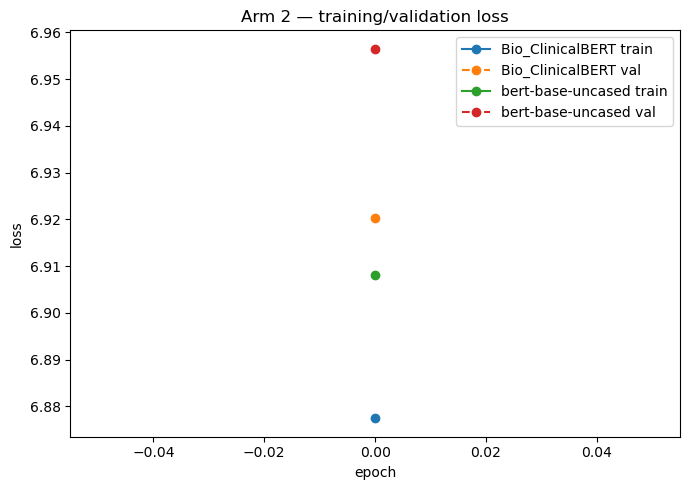

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, history in histories.items():
    short = name.split("/")[-1]
    ax.plot(history["epoch"], history["train_loss"], marker="o", label=f"{short} train")
    ax.plot(history["epoch"], history["val_loss"], marker="o", linestyle="--", label=f"{short} val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Arm 2 — training/validation loss")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig6_loss_curves.png", dpi=150)
plt.show()

## 6. Selection

Epoch/checkpoint selection uses validation accuracy on the **standard hold-out only** -- Arm 2
does not use the shift-aware tie-break rule (that governs Arm 1 index-variant/scheme selection
only, per `CLAUDE.md`). Within-1-SE-prefer-fewest-epochs discipline applies throughout: SE ≈
3.5pp at n=200, so differences below ~7pp are noise.

In [9]:
selected_bioclinicalbert = ab.select_best_epoch_within_one_se(history_bioclinicalbert, n_val=len(val))
selected_bertbase = ab.select_best_epoch_within_one_se(history_bertbase, n_val=len(val))

print("Bio_ClinicalBERT selected epoch (within 1 SE, fewest epochs):")
print(selected_bioclinicalbert)
print()
print("bert-base-uncased selected epoch (within 1 SE, fewest epochs):")
print(selected_bertbase)

acc_diff = abs(selected_bioclinicalbert["val_accuracy"] - selected_bertbase["val_accuracy"])
se = (0.5 * (1 - 0.5) / len(val)) ** 0.5  # conservative SE at p=0.5 for the encoder-vs-encoder gap
print(f"\n|accuracy difference| = {acc_diff:.4f} (SE ~ {se:.4f})")
if acc_diff < se:
    print("Within 1 SE -- unresolved comparison, not declaring a winner.")
    selected_model_name = "emilyalsentzer/Bio_ClinicalBERT"  # default: in-domain pretraining prior
    selected_row = selected_bioclinicalbert
else:
    selected_model_name = (
        "emilyalsentzer/Bio_ClinicalBERT"
        if selected_bioclinicalbert["val_accuracy"] > selected_bertbase["val_accuracy"]
        else "bert-base-uncased"
    )
    selected_row = selected_bioclinicalbert if selected_model_name == "emilyalsentzer/Bio_ClinicalBERT" else selected_bertbase
print(f"selected model: {selected_model_name}")

Bio_ClinicalBERT selected epoch (within 1 SE, fewest epochs):
epoch           0.000000
train_loss      6.877478
val_loss        6.920250
val_accuracy    0.000000
Name: 0, dtype: float64

bert-base-uncased selected epoch (within 1 SE, fewest epochs):
epoch           0.000000
train_loss      6.908128
val_loss        6.956459
val_accuracy    0.000000
Name: 0, dtype: float64

|accuracy difference| = 0.0000 (SE ~ 0.1118)
Within 1 SE -- unresolved comparison, not declaring a winner.
selected model: emilyalsentzer/Bio_ClinicalBERT


## 7. Validation predictions for the selected model

Persisted with per-item top-5 predictions, aligned to validation order -- `05_results` and the
error analysis in §3.3 both need this, and McNemar against Arm 1 needs per-item predictions
aligned to the same validation set.

In [10]:
from transformers import AutoModelForSequenceClassification

# Re-fit the selected model at its selected epoch count to obtain the state dict used for the
# persisted predictions (run_model_ablation already trained it above; retrain isolated to avoid
# holding every encoder's full state_dict in memory across the notebook).
set_seed()
selected_epochs = int(selected_row["epoch"]) + 1
selected_state, _ = ab.train_model(
    fit, val, label_to_id, selected_model_name,
    lr=LEARNING_RATE, batch_size=BATCH_SIZE, epochs=selected_epochs, max_length=MAX_LENGTH, seed=44,
)
final_model = AutoModelForSequenceClassification.from_pretrained(
    selected_model_name, num_labels=len(label_to_id)
)
final_model.load_state_dict(selected_state)
final_model = final_model.to(device)
final_tokeniser = AutoTokenizer.from_pretrained(selected_model_name)

ranked = ab.predict_ranked(
    final_model, final_tokeniser, val["question"].tolist(), id_to_label,
    max_length=MAX_LENGTH, batch_size=BATCH_SIZE, device=device,
)
scores = evaluate.score_ranked(ranked, val["disease"].tolist())
print(scores)

val_predictions = pd.DataFrame({"question": val["question"], "gold": val["disease"]})
val_predictions["pred"] = [r[0] for r in ranked]
for i in range(5):
    val_predictions[f"top_{i + 1}"] = [r[i] if i < len(r) else None for r in ranked]
val_predictions.to_csv(ARTEFACTS_DIR / "arm2_val_predictions.csv", index=False)
val_predictions.head()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

{'accuracy': 0.0, 'acc_at_5': 0.0, 'macro_f1': 0.0, 'mrr': 0.0}


,question,gold,pred,top_1,top_2,top_3,top_4,top_5
0,Are there any support groups for individuals w...,scoliosis,multiple_myeloma,multiple_myeloma,baby_support_and_services_tips_for_new_parents,vitamins_and_minerals_others,scars,botulism
1,Is acupuncture covered by the NHS?,acupuncture,multiple_myeloma,multiple_myeloma,baby_support_and_services_tips_for_new_parents,clinical_trials,hydronephrosis,bad_breath
2,What is Group B strep?,group_b_strep,bad_breath,bad_breath,hydronephrosis,clinical_trials,pregnancy_and_baby_sore_cracked_nipples_breast...,lichen_planus
3,When should I start training my child to use a...,baby_babys_development_potty_training_and_bedw...,multiple_myeloma,multiple_myeloma,hydronephrosis,clinical_trials,cyclospora,bad_breath
4,Can an ingrown toenail heal on its own?,ingrown_toenail,multiple_myeloma,multiple_myeloma,baby_support_and_services_tips_for_new_parents,bad_breath,clinical_trials,hydronephrosis


## 8. Freeze Arm 2 hyperparameters into `config.py`

Values printed here, then copied into `src/amlh/config.py`'s `HYPERPARAMETERS` Arm 2 fields as a
follow-up source edit -- matching how Arm 1's hyperparameters were frozen. **Only valid when
`QUICK_SMOKE_TEST = False`** (a real Colab T4 run) -- the smoke-test run above exists to prove
the notebook's logic is correct, not to supply frozen values.

In [11]:
frozen_arm2_hyperparameters = {
    "bert_model_name": selected_model_name,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "num_epochs": selected_epochs,
}
print(f"QUICK_SMOKE_TEST = {QUICK_SMOKE_TEST}")
if QUICK_SMOKE_TEST:
    print("NOT VALID TO FREEZE -- re-run with QUICK_SMOKE_TEST=False on Colab first.")
print(frozen_arm2_hyperparameters)

QUICK_SMOKE_TEST = True
NOT VALID TO FREEZE -- re-run with QUICK_SMOKE_TEST=False on Colab first.
{'bert_model_name': 'emilyalsentzer/Bio_ClinicalBERT', 'max_length': 48, 'learning_rate': 2e-05, 'batch_size': 8, 'num_epochs': 1}
